In [3]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt

In [4]:
(train_images,train_labels),(test_images,test_labels)=datasets.cifar10.load_data()

In [5]:
print("Train_images",train_images.shape)
print("Train_labels",train_labels.shape)
print(train_images.shape[0],'train samples')
print(test_images.shape[0],'test samples')

Train_images (50000, 32, 32, 3)
Train_labels (50000, 1)
50000 train samples
10000 test samples


In [6]:
train_images,test_images=train_images/255.0,test_images/255.0

In [7]:
class_names=['airplane','automobile','bird','cat','dog','deer','frog','horse','ship','truck']

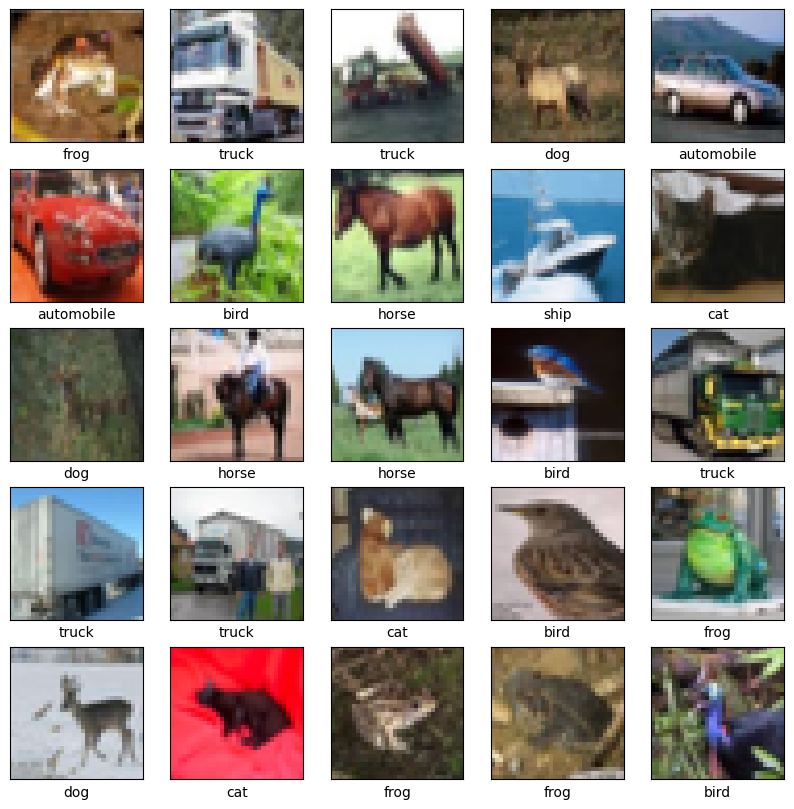

In [13]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow((train_images[i]))
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()   

In [38]:
model=models.Sequential()
model.add(layers.Conv2D(80,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(120,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(160,(3,3),activation='relu'))

In [39]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 80)          │           2,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 15, 80)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 13, 13, 120)         │          86,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 120)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 4, 4, 160)           │         172,960 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 261,720 (1022.34 KB)

 Trainable params: 261,720 (1022.34 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu',kernel_initializer='he_uniform'))
model.add(layers.Dense(10,activation='softmax'))

In [41]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 80)          │           2,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 15, 80)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 13, 13, 120)         │          86,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 120)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 4, 4, 160)           │         172,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │         163,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 426,274 (1.63 MB)

 Trainable params: 426,274 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history=model.fit(train_images,train_labels,epochs=10,validation_data=(test_images,test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.3500 - loss: 1.7588 - val_accuracy: 0.5873 - val_loss: 1.1751
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6030 - loss: 1.1326 - val_accuracy: 0.6610 - val_loss: 0.9780
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6812 - loss: 0.9104 - val_accuracy: 0.6861 - val_loss: 0.9100
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7291 - loss: 0.7777 - val_accuracy: 0.7059 - val_loss: 0.8540
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7609 - loss: 0.6878 - val_accuracy: 0.7077 - val_loss: 0.8545
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7915 - loss: 0.6025 - val_accuracy: 0.7317 - val_loss: 0.8109
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8169 - loss: 0.5332 - val_accuracy: 0.7206 - val_loss: 0.8641
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8387 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7420 - loss: 0.8846


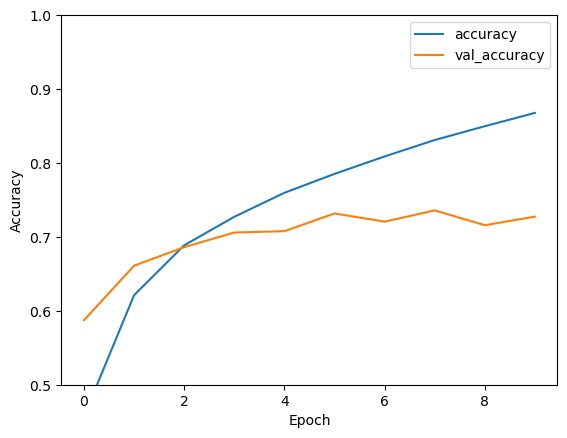

In [43]:
plt.plot(history.history['accuracy'],label=['accuracy'])
plt.plot(history.history['val_accuracy'],label=['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5,1])
plt.legend(loc='upper right')
test_loss,test_acc=model.evaluate(test_images,test_labels)
plt.show()

In [44]:
print(test_acc)

0.727400004863739
